# Sensor Signal Analysis: Comparing Signal Models and Propagation Models

This notebook analyzes sensor signals from passive sonar array simulations, comparing three different signal models with multiple acoustic propagation models:

## Signal Models
1. **TonalSignal**: Basic tonal signal generation (no phase continuity between timesteps)
2. **BlendedTonalSignal**: Uses blending/windowing for smooth phase transitions (40% blend fraction)
3. **OverlapAddTonalSignal**: Ensures phase continuity through overlap-add synthesis

## Propagation Models
1. **Spherical**: Spherical spreading loss model
2. **Bellhop**: Ray-tracing acoustic propagation using BELLHOP
3. **rtrs**: Range-dependent transmission loss using rtrs (multi-frequency support)

## Simulation Scenario
- **Platform**: Stationary ship with 256-element towed array at 200m depth
- **Target**: Moving vessel at 10 knots with three tonal components (10 Hz, 50 Hz, 120 Hz)
- **Environment**: Munk sound speed profile, 5000m depth
- **Analysis**: Focus on middle sensor (sensor 128) across 10 timesteps (2s intervals)

None of these models properly reconstruct the signal at the sensor. For accurate signal reconstruction, use the broadband rtrs method.

## 1. Setup and Import Libraries

In [1]:
"""Import all necessary libraries for passive sonar simulation and signal analysis."""

import numpy as np

np.random.seed(1999)

from datetime import datetime, timedelta
from time import time

import matplotlib.pyplot as plt
from scipy.signal import spectrogram, get_window
from scipy.io import wavfile

from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, FlatBathymetry
from nereus.models.propagation import (
    SphericalAcousticPropagationModel,
    BellhopAcousticPropagationModel,
    rtrsAcousticPropagationModel,
)
from nereus.signal.anthropogenic import TonalSignal, BlendedTonalSignal, OverlapAddTonalSignal
from nereus.signal.ambient import ColouredNoise
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator
from nereus.simulator import PassiveSonarArraySimulator

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 2. Define Simulation Parameters

In [2]:
"""Define all simulation parameters."""

# Simulation parameters
SIM_RATE = 2.0  # seconds per timestep
SIM_PARAMS = {
    "start_time": datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval": timedelta(seconds=SIM_RATE),
    "num_steps": 10,
}

# Platform (ship) parameters - stationary
SHIP_PARAMS = {
    "start_vector": np.array([0, 0, 0, 0, -10.0, 0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

# Towed array parameters
ARRAY_PARAMS = {
    "num_sensors": 256,
    "tow_cable_length": 800.0,
    "sensor_spacing": 1.0,
    "array_depth": -200.0,
}

# Target parameters - moving vessel with tonal signature
TARGET_PARAMS = {
    "start_vector": np.array([-6000, 10, 2000, -1, -10.0, 0]),  # 10 m/s ≈ 20 knots
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0.001), ConstantVelocity(0.001), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([100.0, 100.0, 100.0]) / 20),  # Convert dB to µPa
    "frequencies_hz": np.array([10.0, 50.0, 120.0]),
    "phases_rad": np.array([0.0, 0.0, 0.0]),
}

# Signal parameters
SIGNAL_PARAMS = {
    "duration_s": SIM_RATE,
    "sampling_rate_hz": 500.0,
    "noise_amplitude_upa": 10 ** (15 / 20),
    "noise_spectral_exponent": -5,  # pink noise
}

# Propagation parameters
PROP_PARAMS = {"ssp": Munk()}

# Beamformer parameters
BF_PARAMS = {
    "shading": "blackman",
    "domain": "frequency",
}

# Steering calculator parameters
STEER_PARAMS = {
    "steering_azimuths_rad": np.linspace(0, np.pi, 181),
}

# Which sensor to analyze (middle of array)
SENSOR_TO_ANALYZE = ARRAY_PARAMS["num_sensors"] // 2

print(
    f"Configuration set: {SIM_PARAMS['num_steps']} timesteps, "
    f"{ARRAY_PARAMS['num_sensors']} sensors, analyzing sensor #{SENSOR_TO_ANALYZE}"
)

Configuration set: 10 timesteps, 256 sensors, analyzing sensor #128


## 3. Create Platform and Target Trajectory

In [3]:
"""Create towed array platform and target ground truth trajectory."""

# Create platform with towed array
initial_state = GroundTruthState(SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"])

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_model=SHIP_PARAMS["transition_model"],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Propagate platform through timesteps
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectory with tonal signal metadata
target_states = [
    GroundTruthState(
        TARGET_PARAMS["start_vector"],
        timestamp=SIM_PARAMS["start_time"],
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
]

transition_model = TARGET_PARAMS["transition_model"]
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    time_interval = new_time - target_states[-1].timestamp

    new_state_vector = transition_model.function(
        target_states[-1], noise=True, time_interval=time_interval
    )

    new_state = GroundTruthState(
        new_state_vector,
        timestamp=new_time,
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
    target_states.append(new_state)

target_ground_truth = GroundTruthPath(target_states)

print(f"Platform created with {platform.num_sensors} sensors")
print(f"Target trajectory created with {len(target_states)} states")

Platform created with 256 sensors
Target trajectory created with 10 states


## 4. Initialize Propagation Models

In [4]:
"""Initialize acoustic propagation models."""

prop_models = {
    "Spherical": SphericalAcousticPropagationModel(ssp=PROP_PARAMS["ssp"]),
    "Bellhop": BellhopAcousticPropagationModel(ssp=PROP_PARAMS["ssp"], env_depth=5000.0),
    "rtrs": rtrsAcousticPropagationModel(
        ssp=PROP_PARAMS["ssp"], bathymetry=FlatBathymetry(depth=5000.0), use_all_frequencies=True
    ),
}

print(f"Initialized {len(prop_models)} propagation models: {list(prop_models.keys())}")

Initialized 3 propagation models: ['Spherical', 'Bellhop', 'rtrs']


## 5. Initialize Beamformer and Steering Calculator

In [5]:
"""Initialize beamformer and steering calculator for passive sonar processing."""

das_beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    shading=get_window(BF_PARAMS["shading"], platform.num_sensors),
    domain=BF_PARAMS["domain"],
)

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
)

print(f"Beamformer initialized with {BF_PARAMS['shading']} shading")
print(
    f"Steering calculator initialized with {len(STEER_PARAMS['steering_azimuths_rad'])} azimuths"
)

Beamformer initialized with blackman shading
Steering calculator initialized with 181 azimuths


## 6. Helper Functions for Simulation and Analysis

In [6]:
"""Define helper functions for running simulations and generating signals."""


def run_simulation(signal_model, prop_model, model_name):
    """Run simulation with specified signal and propagation models.

    Args:
        signal_model: Signal generation model
        prop_model: Acoustic propagation model
        model_name: Name for logging

    Returns:
        np.ndarray: Concatenated sensor signals across all timesteps
    """
    # Reset signal model state
    try:
        signal_model.reset()
    except:
        pass

    simulator = PassiveSonarArraySimulator(
        platform=platform,
        propagation_model=prop_model,
        signal_model=signal_model,
        noise_model=None,
        beamformer=das_beamformer,
        steering_calculator=steering_calculator,
        ground_truth_paths=[target_ground_truth],
    )

    # Collect sensor data for all timesteps
    sensor_signals_over_time = []
    data_generator = simulator.sensor_data_gen()

    for timestamp, sensor_data_set in data_generator:
        if sensor_data_set:
            sensor_data = list(sensor_data_set)[0]
            sensor_signal = sensor_data.raw_signals[SENSOR_TO_ANALYZE, :]
            sensor_signals_over_time.append(sensor_signal)

    return np.concatenate(sensor_signals_over_time)


def generate_source_signal(signal_model):
    """Generate source signal without propagation effects.

    Args:
        signal_model: Signal generation model

    Returns:
        np.ndarray: Source signal across all timesteps
    """
    try:
        signal_model.reset()
    except:
        pass

    source_signal_chunks = []
    for i in range(SIM_PARAMS["num_steps"]):
        chunk = signal_model.generate(
            source=target_states[i],
            sensor_delays_s=np.array([0.0]),
            tloss_db=0.0,
            propagation_time_s=0.0,
        )
        source_signal_chunks.append(chunk[0, :])

    return np.concatenate(source_signal_chunks)


def save_as_wav(signal, filename, sampling_rate):
    """Save complex or real signal as WAV file (normalized to int16).

    Args:
        signal: Complex or real signal array
        filename: Output WAV filename
        sampling_rate: Sampling rate in Hz
    """
    if np.iscomplexobj(signal):
        signal_real = np.real(signal)
    else:
        signal_real = signal

    max_val = np.max(np.abs(signal_real))
    if max_val > 0:
        signal_normalized = signal_real / max_val
    else:
        signal_normalized = signal_real

    signal_int16 = np.int16(signal_normalized * 32767)
    wavfile.write(filename, int(sampling_rate), signal_int16)


print("Helper functions defined")

Helper functions defined


---

# Part 1: TonalSignal Model

The **TonalSignal** model generates basic tonal signals without ensuring phase continuity between timesteps. This usually results in phase and amplitude discontinuities at timestep boundaries.

## 7. Run TonalSignal with All Propagation Models

In [ ]:
"""Run simulations with TonalSignal model and all propagation models."""

print("=" * 80)
print("TONAL SIGNAL MODEL")
print("=" * 80)

# Initialize signal model
tonal_signal_model = TonalSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Storage for results
tonal_signals = {}

# Run simulations for each propagation model
for model_name, prop_model in prop_models.items():
    print(f"\nRunning simulation with {model_name}...")
    time_start = time()

    tonal_signals[model_name] = run_simulation(tonal_signal_model, prop_model, model_name)

    time_end = time()
    print(f"Completed in {time_end - time_start:.2f}s")
    print(f"Signal length: {len(tonal_signals[model_name])} samples")

# Generate source signal
print("\nGenerating source signal...")
tonal_source_signal = generate_source_signal(tonal_signal_model)
print(f"Source signal length: {len(tonal_source_signal)} samples")

TONAL SIGNAL MODEL

Running simulation with Spherical...
  ✓ Completed in 1.98s
  ✓ Signal length: 10000 samples

Running simulation with Bellhop...
  ✓ Completed in 2.97s
  ✓ Signal length: 10000 samples

Running simulation with rtrs...
  ✓ Completed in 8.61s
  ✓ Signal length: 10000 samples

Generating source signal...
Source signal length: 10000 samples


## 8. Visualize TonalSignal Results

/var/folders/_h/rh9qx_4d76b6mn_86t804sq80000gn/T/ipykernel_87937/3829963836.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


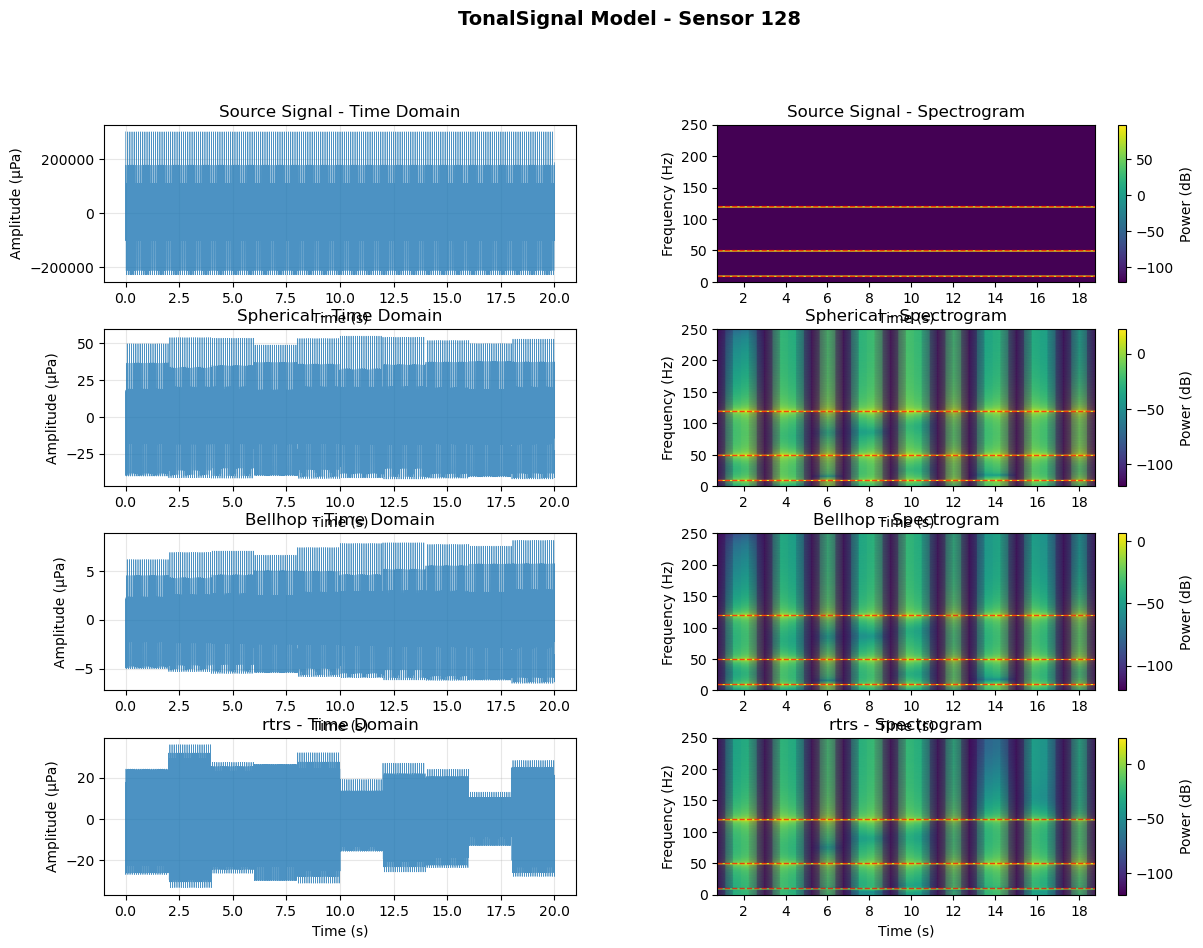

In [8]:
"""Visualize time-domain signals and spectrograms for TonalSignal."""

total_samples = len(tonal_source_signal)
time_axis = np.arange(total_samples) / SIGNAL_PARAMS["sampling_rate_hz"]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(len(prop_models) + 1, 2, hspace=0.3, wspace=0.3)

# Plot source signal
ax_src_time = fig.add_subplot(gs[0, 0])
ax_src_time.plot(time_axis, np.real(tonal_source_signal), linewidth=0.5, alpha=0.8)
ax_src_time.set_xlabel("Time (s)")
ax_src_time.set_ylabel("Amplitude (µPa)")
ax_src_time.set_title("Source Signal - Time Domain")
ax_src_time.grid(True, alpha=0.3)

ax_src_spec = fig.add_subplot(gs[0, 1])
nperseg = int(SIGNAL_PARAMS["sampling_rate_hz"] * 1.5)
noverlap = nperseg // 2
f_src, t_src, Sxx_src = spectrogram(
    np.real(tonal_source_signal),
    fs=SIGNAL_PARAMS["sampling_rate_hz"],
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)
Sxx_src_db = 10 * np.log10(np.abs(Sxx_src) + 1e-12)
im_src = ax_src_spec.pcolormesh(t_src, f_src, Sxx_src_db, shading="gouraud", cmap="viridis")
ax_src_spec.set_xlabel("Time (s)")
ax_src_spec.set_ylabel("Frequency (Hz)")
ax_src_spec.set_title("Source Signal - Spectrogram")
ax_src_spec.set_ylim([0, 250])
plt.colorbar(im_src, ax=ax_src_spec, label="Power (dB)")
for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_src_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

# Plot received signals for each propagation model
for idx, (model_name, signal) in enumerate(tonal_signals.items(), start=1):
    # Time domain
    ax_time = fig.add_subplot(gs[idx, 0])
    ax_time.plot(time_axis, np.real(signal), linewidth=0.5, alpha=0.8)
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Amplitude (µPa)")
    ax_time.set_title(f"{model_name} - Time Domain")
    ax_time.grid(True, alpha=0.3)

    # Spectrogram
    ax_spec = fig.add_subplot(gs[idx, 1])
    f, t, Sxx = spectrogram(
        np.real(signal),
        fs=SIGNAL_PARAMS["sampling_rate_hz"],
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )
    Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-12)
    im = ax_spec.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="viridis")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_title(f"{model_name} - Spectrogram")
    ax_spec.set_ylim([0, 250])
    plt.colorbar(im, ax=ax_spec, label="Power (dB)")
    for freq in TARGET_PARAMS["frequencies_hz"]:
        ax_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

plt.suptitle(
    f"TonalSignal Model - Sensor {SENSOR_TO_ANALYZE}", fontsize=14, fontweight="bold", y=0.995
)
plt.tight_layout()
plt.show()

---

# Part 2: BlendedTonalSignal Model

The **BlendedTonalSignal** model uses windowing/blending (40% blend fraction) to create smoother phase transitions between timesteps, reducing discontinuities. 

## 9. Run BlendedTonalSignal with All Propagation Models

In [ ]:
"""Run simulations with BlendedTonalSignal model and all propagation models."""

print("=" * 80)
print("BLENDED TONAL SIGNAL MODEL")
print("=" * 80)

# Initialize signal model
blended_signal_model = BlendedTonalSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    blend_fraction=0.40,  # 40% overlap for continuity
)

# Storage for results
blended_signals = {}

# Run simulations for each propagation model
for model_name, prop_model in prop_models.items():
    print(f"\nRunning simulation with {model_name}...")
    time_start = time()

    blended_signals[model_name] = run_simulation(blended_signal_model, prop_model, model_name)

    time_end = time()
    print(f"Completed in {time_end - time_start:.2f}s")
    print(f"Signal length: {len(blended_signals[model_name])} samples")

# Generate source signal
print("\nGenerating source signal...")
blended_source_signal = generate_source_signal(blended_signal_model)
print(f"Source signal length: {len(blended_source_signal)} samples")

BLENDED TONAL SIGNAL MODEL

Running simulation with Spherical...
  ✓ Completed in 1.99s
  ✓ Signal length: 10000 samples

Running simulation with Bellhop...
  ✓ Completed in 3.22s
  ✓ Signal length: 10000 samples

Running simulation with rtrs...
  ✓ Completed in 8.33s
  ✓ Signal length: 10000 samples

Generating source signal...
  ✓ Source signal length: 10000 samples


## 10. Visualize BlendedTonalSignal Results

/var/folders/_h/rh9qx_4d76b6mn_86t804sq80000gn/T/ipykernel_87937/4205131183.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


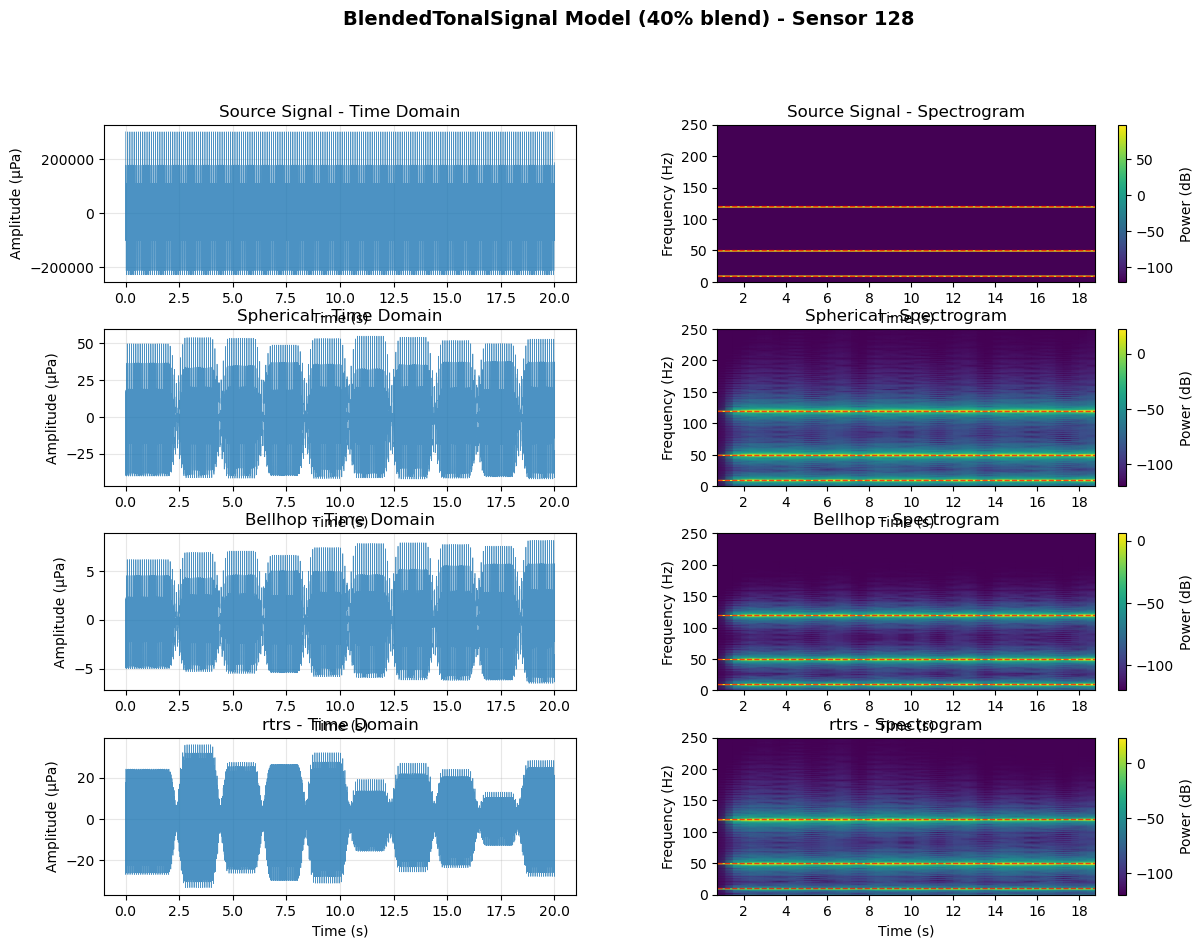

In [10]:
"""Visualize time-domain signals and spectrograms for BlendedTonalSignal."""

time_axis = np.arange(len(blended_source_signal)) / SIGNAL_PARAMS["sampling_rate_hz"]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(len(prop_models) + 1, 2, hspace=0.3, wspace=0.3)

# Plot source signal
ax_src_time = fig.add_subplot(gs[0, 0])
ax_src_time.plot(time_axis, np.real(blended_source_signal), linewidth=0.5, alpha=0.8)
ax_src_time.set_xlabel("Time (s)")
ax_src_time.set_ylabel("Amplitude (µPa)")
ax_src_time.set_title("Source Signal - Time Domain")
ax_src_time.grid(True, alpha=0.3)

ax_src_spec = fig.add_subplot(gs[0, 1])
nperseg = int(SIGNAL_PARAMS["sampling_rate_hz"] * 1.5)
noverlap = nperseg // 2
f_src, t_src, Sxx_src = spectrogram(
    np.real(blended_source_signal),
    fs=SIGNAL_PARAMS["sampling_rate_hz"],
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)
Sxx_src_db = 10 * np.log10(np.abs(Sxx_src) + 1e-12)
im_src = ax_src_spec.pcolormesh(t_src, f_src, Sxx_src_db, shading="gouraud", cmap="viridis")
ax_src_spec.set_xlabel("Time (s)")
ax_src_spec.set_ylabel("Frequency (Hz)")
ax_src_spec.set_title("Source Signal - Spectrogram")
ax_src_spec.set_ylim([0, 250])
plt.colorbar(im_src, ax=ax_src_spec, label="Power (dB)")
for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_src_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

# Plot received signals for each propagation model
for idx, (model_name, signal) in enumerate(blended_signals.items(), start=1):
    # Time domain
    ax_time = fig.add_subplot(gs[idx, 0])
    ax_time.plot(time_axis, np.real(signal), linewidth=0.5, alpha=0.8)
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Amplitude (µPa)")
    ax_time.set_title(f"{model_name} - Time Domain")
    ax_time.grid(True, alpha=0.3)

    # Spectrogram
    ax_spec = fig.add_subplot(gs[idx, 1])
    f, t, Sxx = spectrogram(
        np.real(signal),
        fs=SIGNAL_PARAMS["sampling_rate_hz"],
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )
    Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-12)
    im = ax_spec.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="viridis")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_title(f"{model_name} - Spectrogram")
    ax_spec.set_ylim([0, 250])
    plt.colorbar(im, ax=ax_spec, label="Power (dB)")
    for freq in TARGET_PARAMS["frequencies_hz"]:
        ax_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

plt.suptitle(
    f"BlendedTonalSignal Model (40% blend) - Sensor {SENSOR_TO_ANALYZE}",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

---

# Part 3: OverlapAddTonalSignal Model

The **OverlapAddTonalSignal** model ensures perfect phase continuity through overlap-add synthesis, maintaining coherent phase across all timestep boundaries.

## 11. Run OverlapAddTonalSignal with All Propagation Models

In [ ]:
"""Run simulations with OverlapAddTonalSignal model and all propagation models."""

print("=" * 80)
print("OVERLAP-ADD TONAL SIGNAL MODEL")
print("=" * 80)

# Initialize signal model
overlap_signal_model = OverlapAddTonalSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Storage for results
overlap_signals = {}

# Run simulations for each propagation model
for model_name, prop_model in prop_models.items():
    print(f"\nRunning simulation with {model_name}...")
    time_start = time()

    overlap_signals[model_name] = run_simulation(overlap_signal_model, prop_model, model_name)

    time_end = time()
    print(f"Completed in {time_end - time_start:.2f}s")
    print(f"Signal length: {len(overlap_signals[model_name])} samples")

# Generate source signal
print("\nGenerating source signal...")
overlap_source_signal = generate_source_signal(overlap_signal_model)
print(f"Source signal length: {len(overlap_source_signal)} samples")

OVERLAP-ADD TONAL SIGNAL MODEL

Running simulation with Spherical...
  ✓ Completed in 2.75s
  ✓ Signal length: 10000 samples

Running simulation with Bellhop...
  ✓ Completed in 4.60s
  ✓ Signal length: 10000 samples

Running simulation with rtrs...
  ✓ Completed in 8.84s
  ✓ Signal length: 10000 samples

Generating source signal...
  ✓ Source signal length: 10000 samples


## 12. Visualize OverlapAddTonalSignal Results

/var/folders/_h/rh9qx_4d76b6mn_86t804sq80000gn/T/ipykernel_87937/3896792793.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


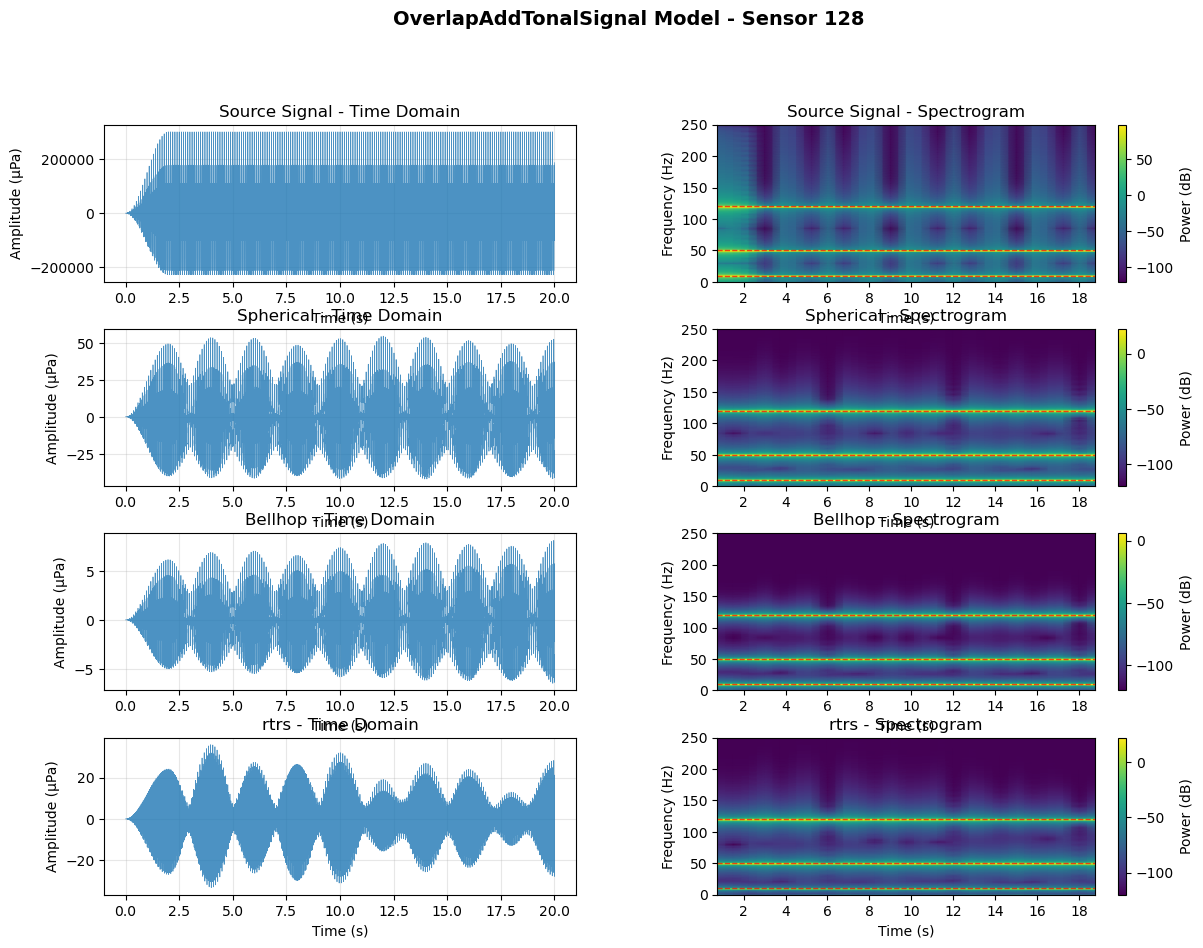

In [12]:
"""Visualize time-domain signals and spectrograms for OverlapAddTonalSignal."""

time_axis = np.arange(len(overlap_source_signal)) / SIGNAL_PARAMS["sampling_rate_hz"]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(len(prop_models) + 1, 2, hspace=0.3, wspace=0.3)

# Plot source signal
ax_src_time = fig.add_subplot(gs[0, 0])
ax_src_time.plot(time_axis, np.real(overlap_source_signal), linewidth=0.5, alpha=0.8)
ax_src_time.set_xlabel("Time (s)")
ax_src_time.set_ylabel("Amplitude (µPa)")
ax_src_time.set_title("Source Signal - Time Domain")
ax_src_time.grid(True, alpha=0.3)

ax_src_spec = fig.add_subplot(gs[0, 1])
nperseg = int(SIGNAL_PARAMS["sampling_rate_hz"] * 1.5)
noverlap = nperseg // 2
f_src, t_src, Sxx_src = spectrogram(
    np.real(overlap_source_signal),
    fs=SIGNAL_PARAMS["sampling_rate_hz"],
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)
Sxx_src_db = 10 * np.log10(np.abs(Sxx_src) + 1e-12)
im_src = ax_src_spec.pcolormesh(t_src, f_src, Sxx_src_db, shading="gouraud", cmap="viridis")
ax_src_spec.set_xlabel("Time (s)")
ax_src_spec.set_ylabel("Frequency (Hz)")
ax_src_spec.set_title("Source Signal - Spectrogram")
ax_src_spec.set_ylim([0, 250])
plt.colorbar(im_src, ax=ax_src_spec, label="Power (dB)")
for freq in TARGET_PARAMS["frequencies_hz"]:
    ax_src_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

# Plot received signals for each propagation model
for idx, (model_name, signal) in enumerate(overlap_signals.items(), start=1):
    # Time domain
    ax_time = fig.add_subplot(gs[idx, 0])
    ax_time.plot(time_axis, np.real(signal), linewidth=0.5, alpha=0.8)
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Amplitude (µPa)")
    ax_time.set_title(f"{model_name} - Time Domain")
    ax_time.grid(True, alpha=0.3)

    # Spectrogram
    ax_spec = fig.add_subplot(gs[idx, 1])
    f, t, Sxx = spectrogram(
        np.real(signal),
        fs=SIGNAL_PARAMS["sampling_rate_hz"],
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )
    Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-12)
    im = ax_spec.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="viridis")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_title(f"{model_name} - Spectrogram")
    ax_spec.set_ylim([0, 250])
    plt.colorbar(im, ax=ax_spec, label="Power (dB)")
    for freq in TARGET_PARAMS["frequencies_hz"]:
        ax_spec.axhline(freq, color="red", linestyle="--", alpha=0.7, linewidth=1)

plt.suptitle(
    f"OverlapAddTonalSignal Model - Sensor {SENSOR_TO_ANALYZE}",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

---

# Part 4: Comparative

Compare phase characteristics, signal power, and frequency spectra across all signal and propagation models.

## 13. Compare Signal Power Over Time

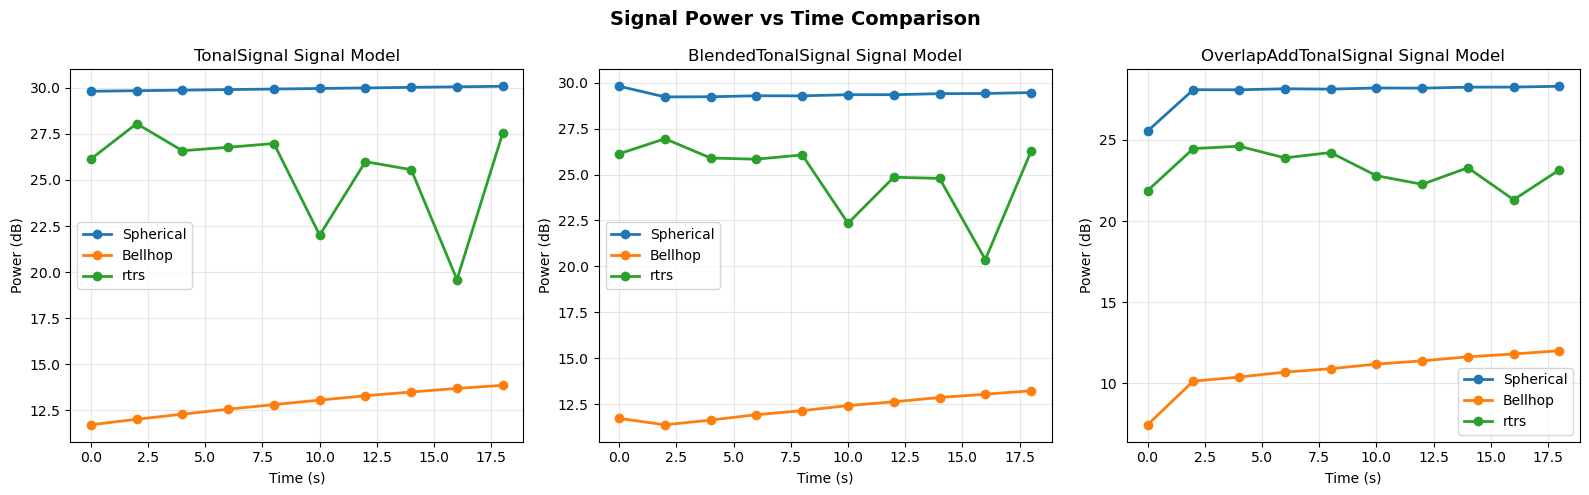

In [14]:
"""Compare signal power over time for all combinations."""

all_signal_models = {
    "TonalSignal": tonal_signals,
    "BlendedTonalSignal": blended_signals,
    "OverlapAddTonalSignal": overlap_signals,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (signal_model_name, signals_dict) in enumerate(all_signal_models.items()):
    ax = axes[idx]

    for prop_model_name, signal in signals_dict.items():
        # Calculate power in windows
        window_size = int(SIGNAL_PARAMS["sampling_rate_hz"] * SIGNAL_PARAMS["duration_s"])
        num_windows = len(signal) // window_size
        powers = []
        window_times = []

        for i in range(num_windows):
            start_idx = i * window_size
            end_idx = start_idx + window_size
            window_signal = signal[start_idx:end_idx]
            power = np.mean(np.abs(window_signal) ** 2)
            powers.append(10 * np.log10(power + 1e-12))
            window_times.append(i * SIGNAL_PARAMS["duration_s"])

        ax.plot(window_times, powers, marker="o", label=prop_model_name, linewidth=2)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Power (dB)")
    ax.set_title(f"{signal_model_name} Signal Model")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Signal Power vs Time Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Compare Frequency Spectra

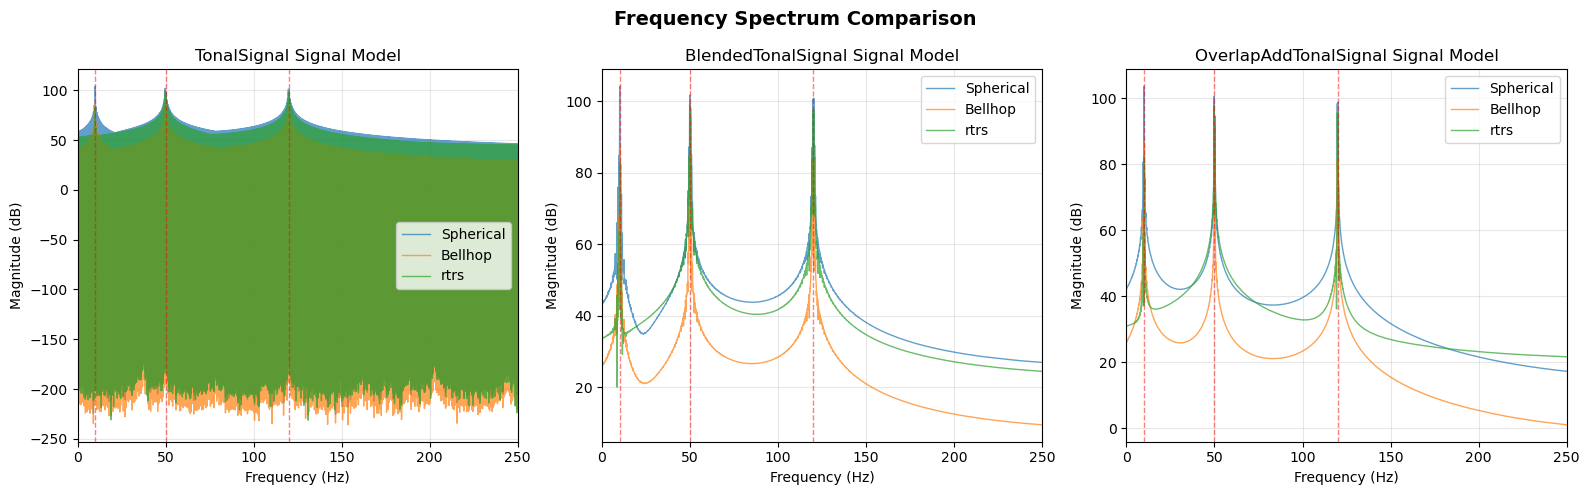

In [15]:
"""Compare frequency spectra for all combinations."""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (signal_model_name, signals_dict) in enumerate(all_signal_models.items()):
    ax = axes[idx]

    for prop_model_name, signal in signals_dict.items():
        # Compute FFT
        fft_signal = np.fft.fft(signal)
        fft_freq = np.fft.fftfreq(len(signal), 1 / SIGNAL_PARAMS["sampling_rate_hz"])

        # Take only positive frequencies
        pos_mask = fft_freq > 0
        fft_freq_pos = fft_freq[pos_mask]
        fft_magnitude = np.abs(fft_signal[pos_mask])
        fft_db = 20 * np.log10(fft_magnitude + 1e-12)

        ax.plot(fft_freq_pos, fft_db, label=prop_model_name, alpha=0.7, linewidth=1)

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"{signal_model_name} Signal Model")
    ax.set_xlim([0, 250])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add vertical lines for target frequencies
    for freq in TARGET_PARAMS["frequencies_hz"]:
        ax.axvline(freq, color="red", linestyle="--", alpha=0.5, linewidth=1)

plt.suptitle("Frequency Spectrum Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 15. Compare Absolute Pressure Envelopes

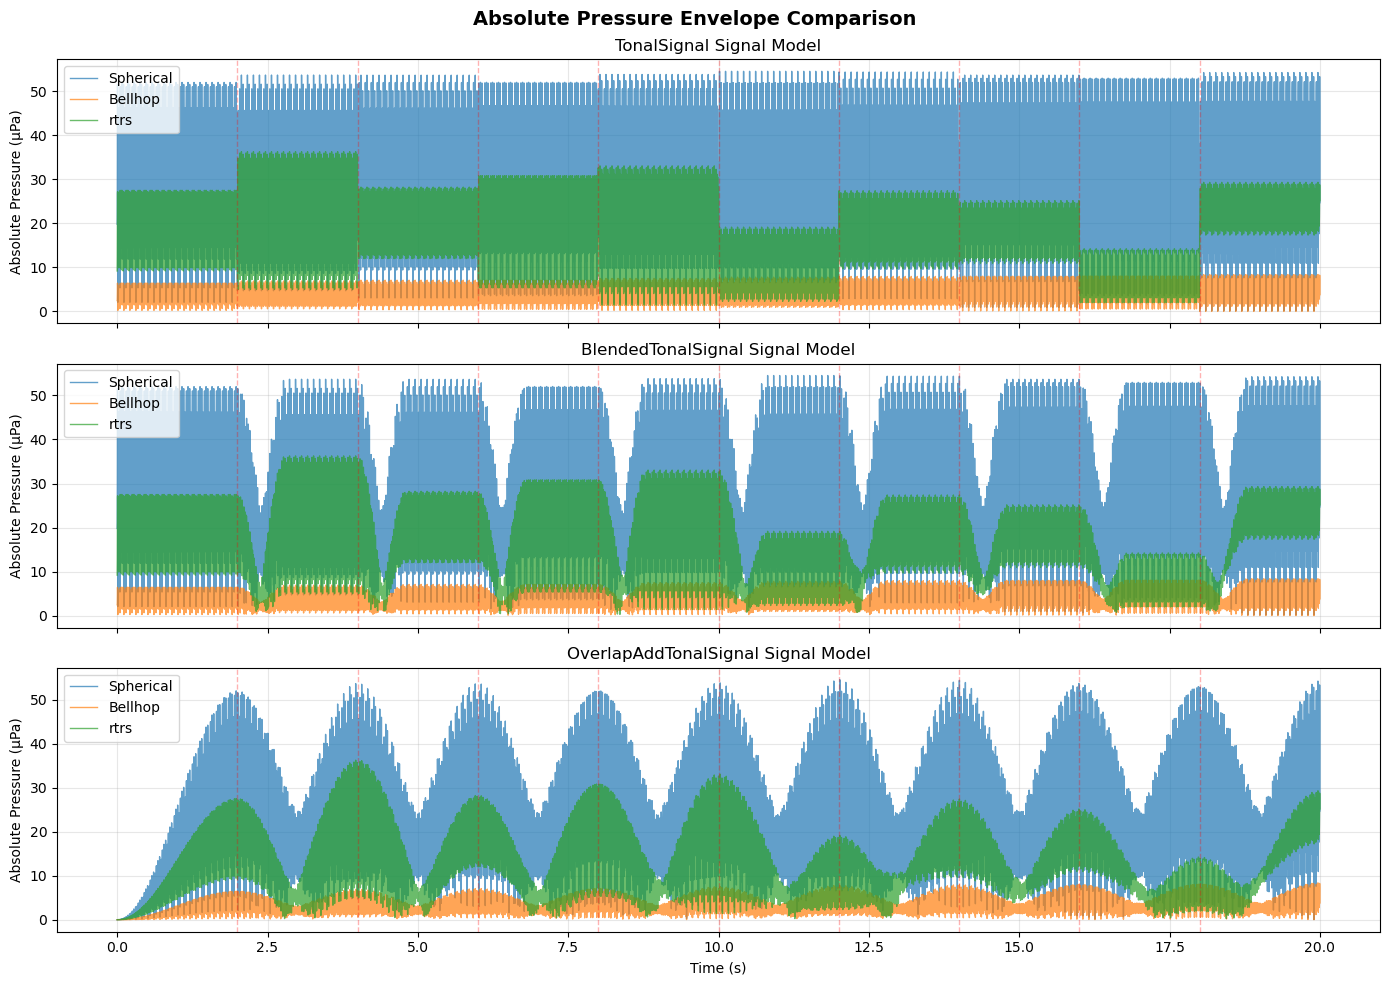

In [16]:
"""Compare absolute pressure envelopes for all combinations."""

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, (signal_model_name, signals_dict) in enumerate(all_signal_models.items()):
    ax = axes[idx]

    for prop_model_name, signal in signals_dict.items():
        time_axis = np.arange(len(signal)) / SIGNAL_PARAMS["sampling_rate_hz"]
        abs_pressure = np.abs(signal)
        ax.plot(time_axis, abs_pressure, label=prop_model_name, linewidth=1, alpha=0.7)

    ax.set_ylabel("Absolute Pressure (µPa)")
    ax.set_title(f"{signal_model_name} Signal Model")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark timestep boundaries
    for i in range(1, SIM_PARAMS["num_steps"]):
        ax.axvline(
            i * SIGNAL_PARAMS["duration_s"], color="red", linestyle="--", alpha=0.3, linewidth=1
        )

axes[-1].set_xlabel("Time (s)")
plt.suptitle("Absolute Pressure Envelope Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

# Part 5: Export WAV Files

Save all source and received signals as WAV files for external analysis.

## 16. Save All Signals as WAV Files

In [ ]:
"""Save all source and received signals as WAV files."""

import os

# Create wavs directory if it doesn't exist
os.makedirs("wavs", exist_ok=True)

print("Saving WAV files...")
print("=" * 60)

# Save source signals
source_signals_dict = {
    "tonal": tonal_source_signal,
    "blended": blended_source_signal,
    "overlapadd": overlap_source_signal,
}

for signal_model_name, source_signal in source_signals_dict.items():
    filename = f"wavs/source_signal_{signal_model_name}.wav"
    save_as_wav(source_signal, filename, SIGNAL_PARAMS["sampling_rate_hz"])
    print(f"Saved: {filename}")

print()

# Save received signals for all combinations
all_received_signals = {
    "tonal": tonal_signals,
    "blended": blended_signals,
    "overlapadd": overlap_signals,
}

for signal_model_name, signals_dict in all_received_signals.items():
    for prop_model_name, received_signal in signals_dict.items():
        prop_name_clean = (
            prop_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        )
        filename = f"wavs/received_{signal_model_name}_{prop_name_clean}.wav"
        save_as_wav(received_signal, filename, SIGNAL_PARAMS["sampling_rate_hz"])
        print(f"Saved: {filename}")

print("\n" + "=" * 60)
print(
    f"Total WAV files saved: {len(source_signals_dict) + sum(len(s) for s in all_received_signals.values())}"
)

Saving WAV files...
✓ Saved: wavs/source_signal_tonal.wav
✓ Saved: wavs/source_signal_blended.wav
✓ Saved: wavs/source_signal_overlapadd.wav

Saved: wavs/received_tonal_spherical.wav
Saved: wavs/received_tonal_bellhop.wav
Saved: wavs/received_tonal_rtrs.wav
Saved: wavs/received_blended_spherical.wav
Saved: wavs/received_blended_bellhop.wav
Saved: wavs/received_blended_rtrs.wav
Saved: wavs/received_overlapadd_spherical.wav
Saved: wavs/received_overlapadd_bellhop.wav
Saved: wavs/received_overlapadd_rtrs.wav

Total WAV files saved: 12
